In [1]:
import os
import torch
import json
from io import BytesIO
import numpy as np
import torch.nn as nn
import imageio.v2 as imageio
from tqdm import tqdm, trange
from utils import SphericalNODataset, get_cr_dirs
# from hux_utils import get_hux_pred, HUXDataset
from neuralop.models import SFNO
from model import MultiModalSFNO
import matplotlib.pyplot as plt
from psipy.model import MASOutput
import cv2 as cv
from mpl_toolkits.axes_grid1 import make_axes_locatable

/Users/reza/Career/DMLab/SURROGATE/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [2]:
device = torch.device('cpu')

In [3]:
data_path = "/Users/reza/Career/DMLab/SURROGATE/Data/all-components/test"
result_paths = [
    "/Users/reza/Career/DMLab/SURROGATE/results/sfno-multimodal/exp_53", # no physics   
    "/Users/reza/Career/DMLab/SURROGATE/results/sfno-multimodal/exp_54", # with physics
]
cfg_paths = [
    os.path.join(result_path, "cfg.json") for result_path in result_paths
]
cfgs = []
for cfg_path in cfg_paths:
    with open(cfg_path, "r") as f:
        cfg = json.load(f)
        cfgs.append(cfg)

In [4]:
len(cfg['train_files'])

320

In [5]:
cr_paths = get_cr_dirs(data_path)

In [10]:
# cfg, result_path = cfgs[0], result_paths[0] # no physics
cfg, result_path = cfgs[1], result_paths[1] # with physics

In [11]:
dataset = SphericalNODataset(
    data_path,
    cr_paths,
    br_min = cfg['br_min'],
    br_max = cfg['br_max'],
    bp_min = cfg['bp_min'],
    bp_max = cfg['bp_max'],
    bt_min = cfg['bt_min'],
    bt_max = cfg['bt_max'],
    jr_min = cfg['jr_min'],
    jr_max = cfg['jr_max'],
    jp_min = cfg['jp_min'],
    jp_max = cfg['jp_max'],
    jt_min = cfg['jt_min'],
    jt_max = cfg['jt_max'],
    # positional_embedding='pt'
)
# hux_dataset = HUXDataset(data_path, cr_paths)

Loading simulations: 100%|██████████| 6/6 [00:10<00:00,  1.72s/it]


In [12]:
sfno = SFNO(
    n_modes=(110, 128),
    in_channels=6 * cfg["encoder_hidden_channels"],
    out_channels=6 * 139,
    hidden_channels=cfg["hidden_channels"],
    projection_channel_ratio=2,
    factorization="dense",
    n_layers=cfg["n_layers"],
    positional_embedding=None,
)
checkpoint = torch.load(
    os.path.join(result_path, "model.pt"), map_location=device, weights_only=False
)
# # If checkpoint is a dict with 'model_state_dict' or similar
# if "state_dict" in checkpoint:
#     state_dict = checkpoint["state_dict"]
# elif "model_state_dict" in checkpoint:
#     state_dict = checkpoint["model_state_dict"]
# else:
#     print("Warning: checkpoint format not recognized")
#     # assume it's already the raw state dict (rarely)
#     state_dict = checkpoint
    
model = MultiModalSFNO(
    in_comp=6,
    out_comp=6,
    n_radii=139,
    d_hidden=cfg["encoder_hidden_channels"],
    sfno=sfno
)
model.load_state_dict(checkpoint, strict=False)

_IncompatibleKeys(missing_keys=[], unexpected_keys=['_metadata'])

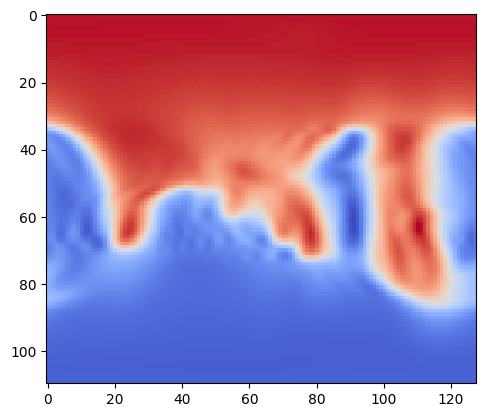

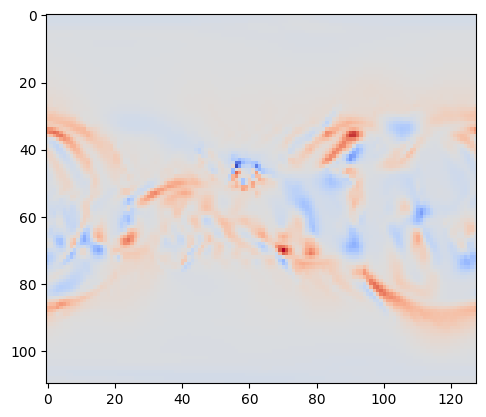

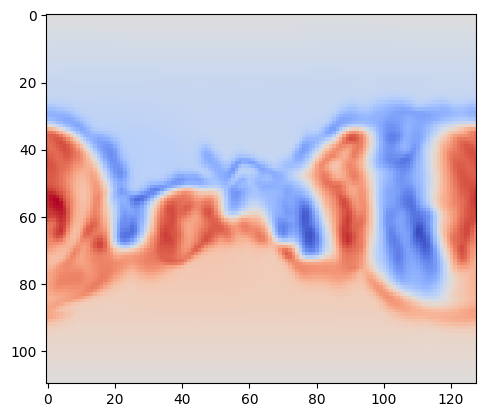

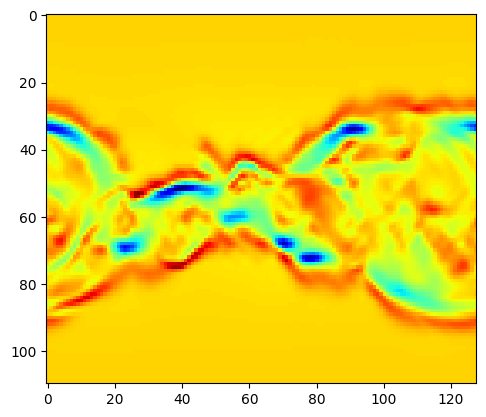

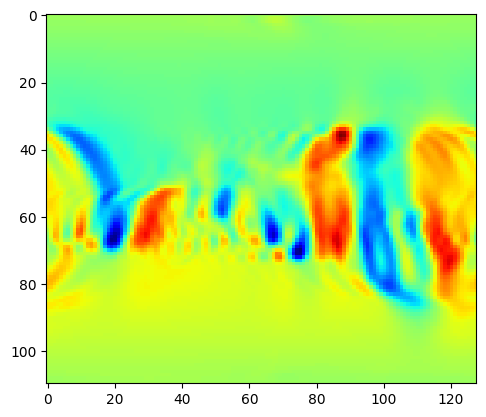

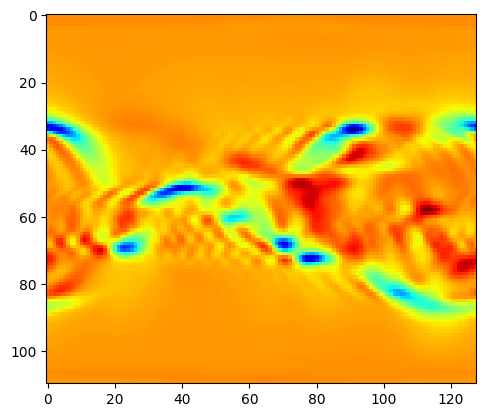

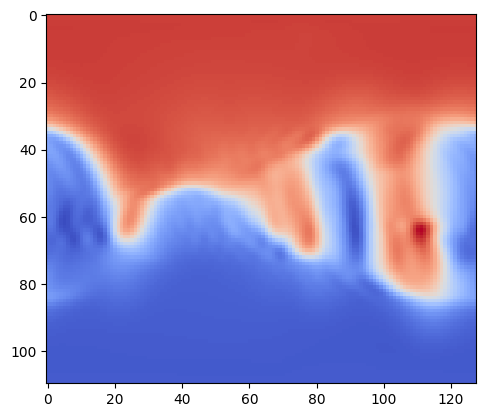

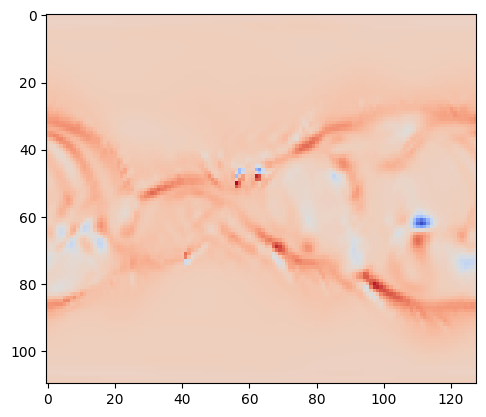

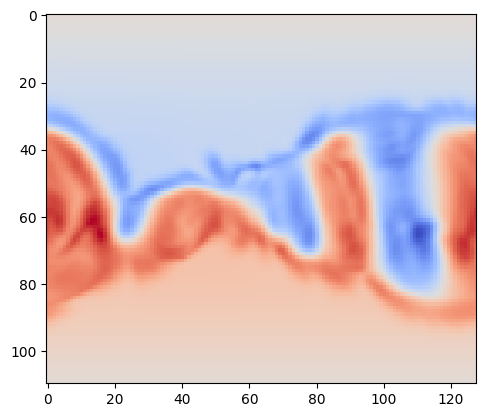

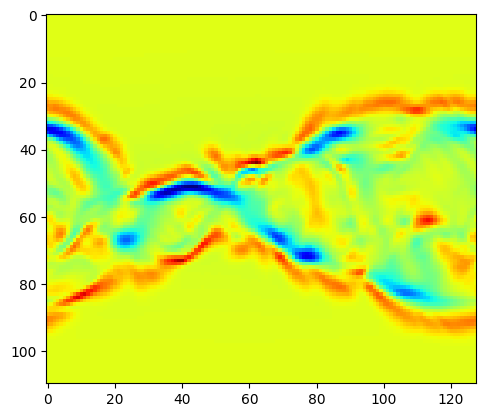

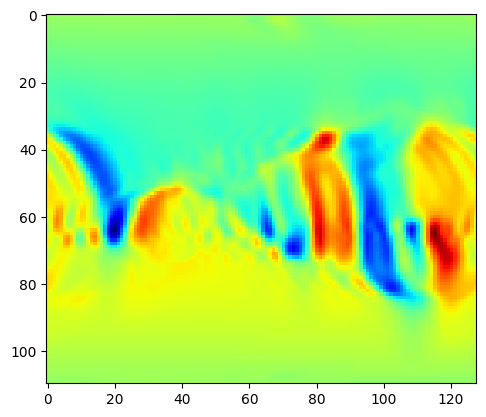

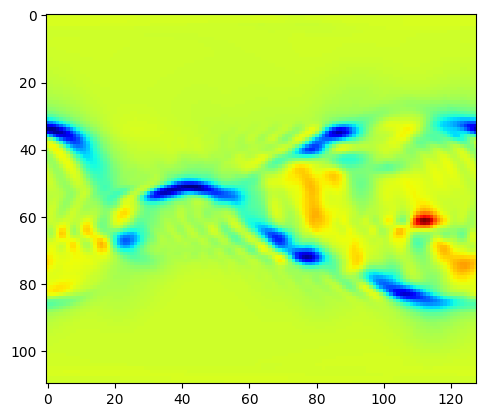

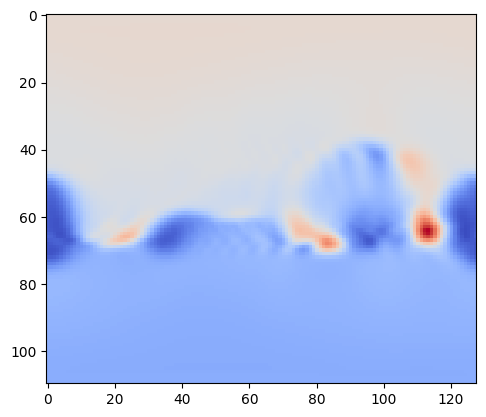

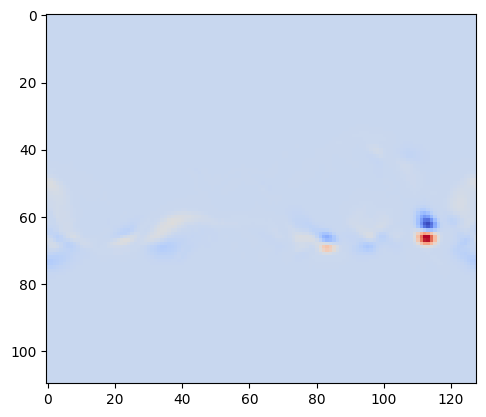

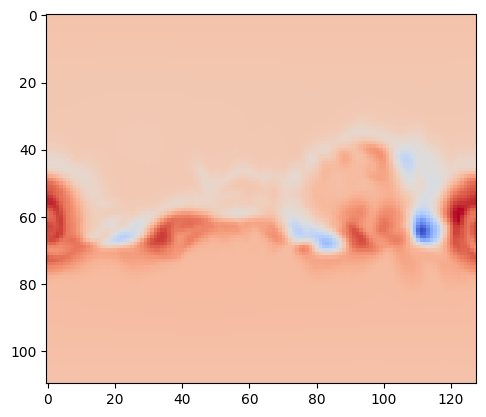

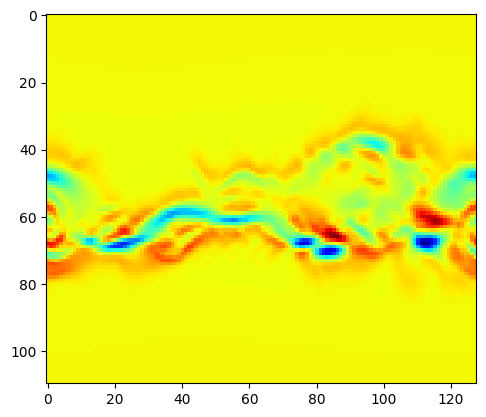

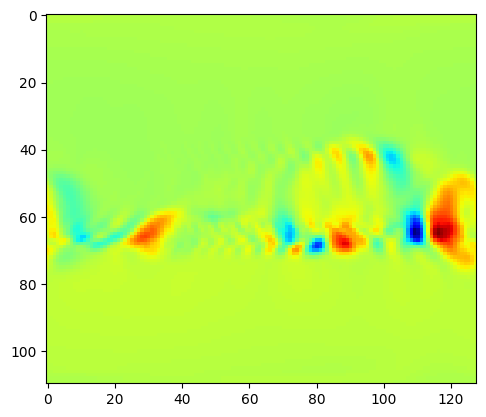

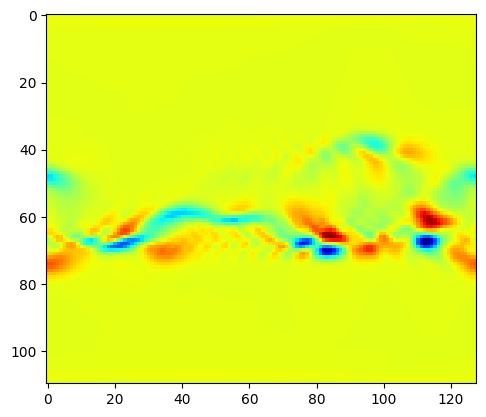

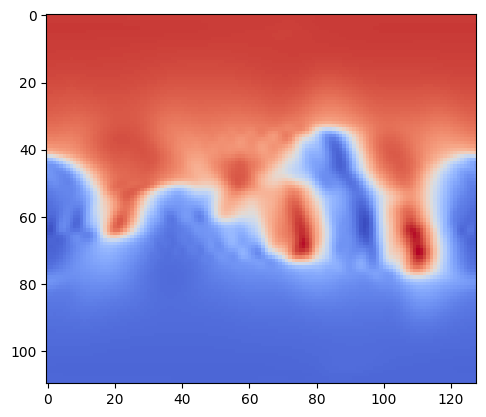

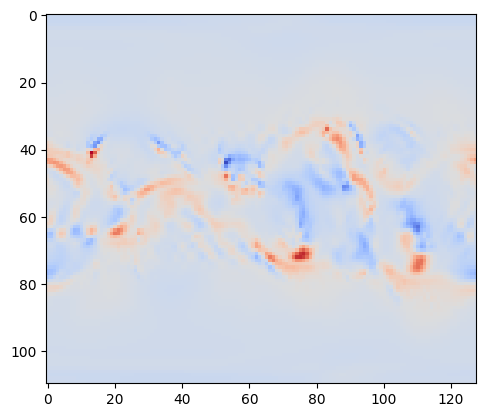

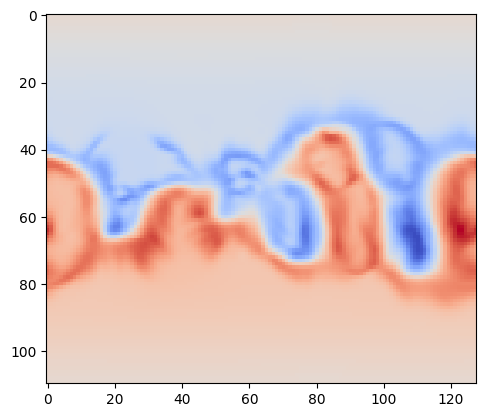

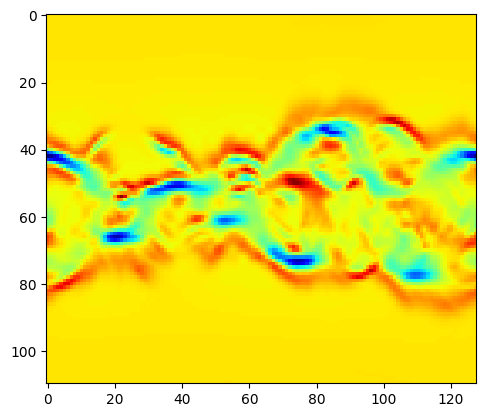

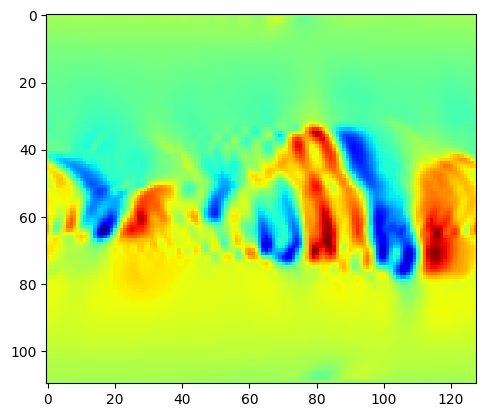

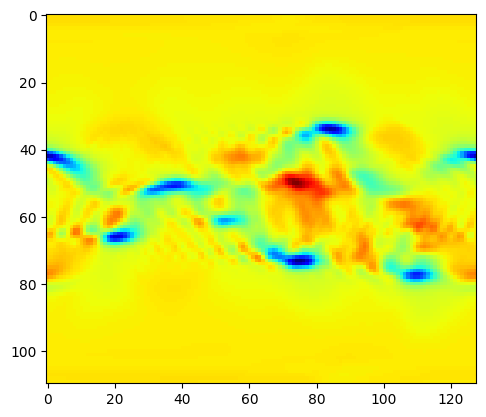

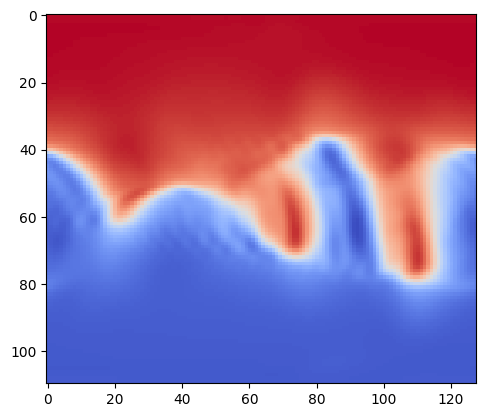

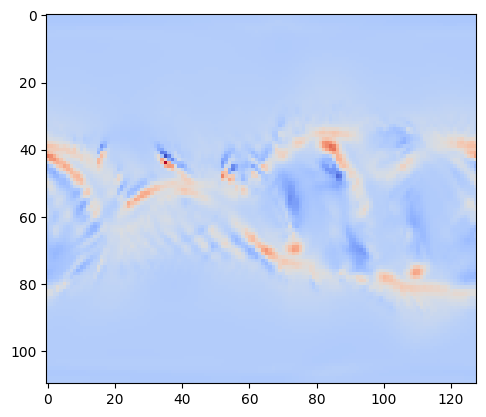

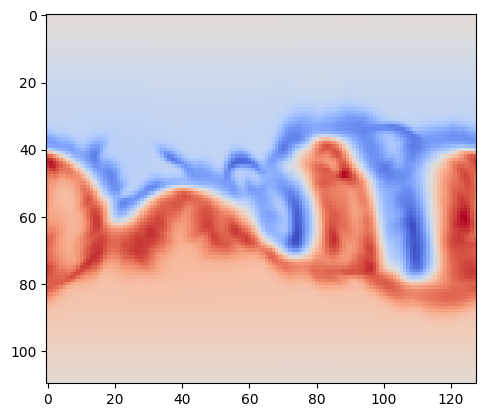

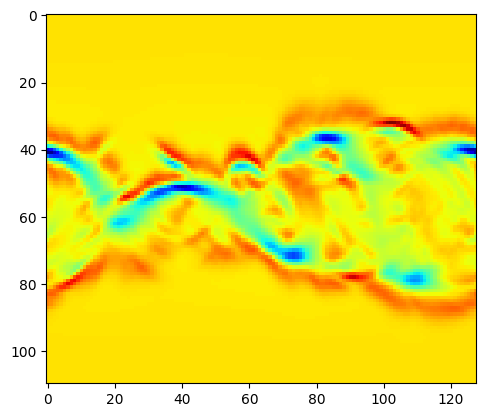

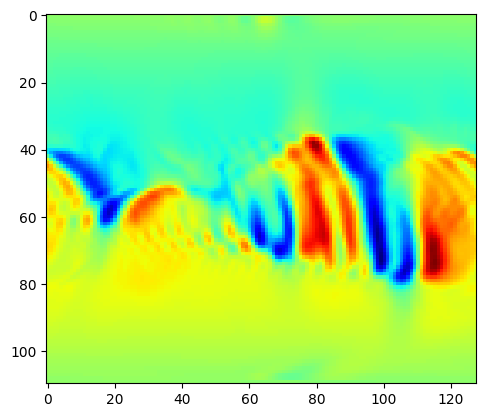

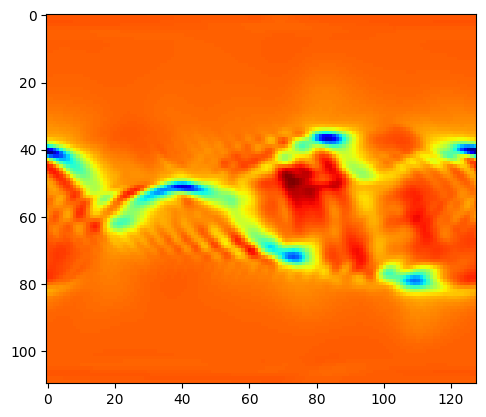

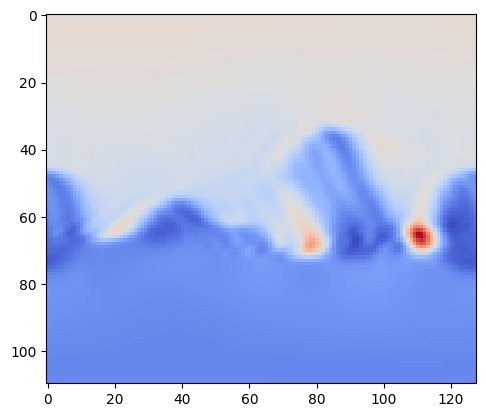

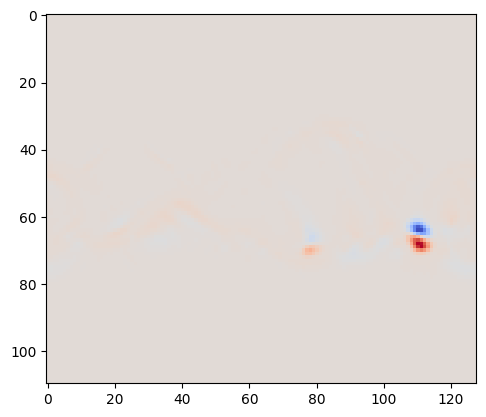

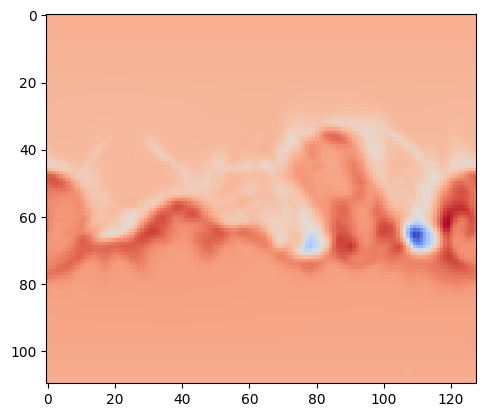

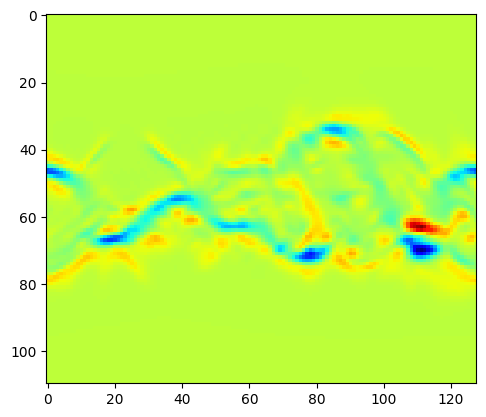

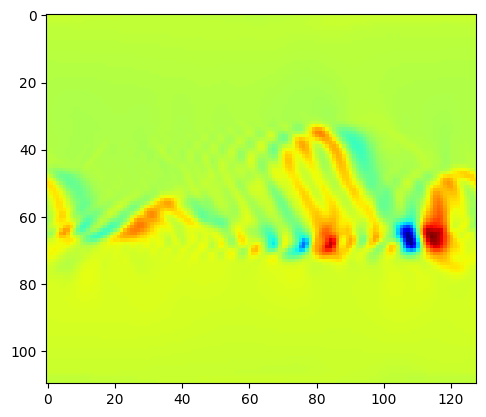

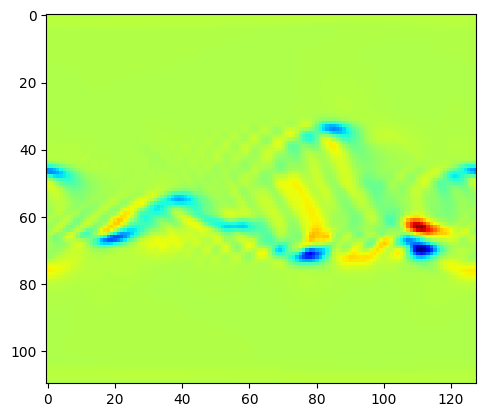

In [13]:
for III in range(len(dataset)):
    plt.imshow(dataset[III]["brx"][0], cmap='coolwarm')
    plt.show()
    plt.imshow(dataset[III]["btx"][0], cmap='coolwarm')
    plt.show()
    plt.imshow(dataset[III]["bpx"][0], cmap='coolwarm')
    plt.show()
    plt.imshow(dataset[III]["jrx"][0], cmap='jet_r')
    plt.show()
    plt.imshow(dataset[III]["jtx"][0], cmap='jet_r')
    plt.show()
    plt.imshow(dataset[III]["jpx"][0], cmap='jet_r')
    plt.show()
    # print(dataset[III]["vx"], III)

In [26]:
I = 2
brx, btx, bpx, jrx, jtx, jpx, bry, bty, bpy, jry, jty, jpy = (
    dataset[I]["brx"],
    dataset[I]["btx"],
    dataset[I]["bpx"],
    dataset[I]["jrx"],
    dataset[I]["jtx"],
    dataset[I]["jpx"],
    dataset[I]["bry"],
    dataset[I]["bty"],
    dataset[I]["bpy"],
    dataset[I]["jry"],
    dataset[I]["jty"],
    dataset[I]["jpy"],
)

print(brx.shape, btx.shape, bpx.shape, jrx.shape, jtx.shape, jpx.shape)

brx = brx.unsqueeze(1).to(device)
btx = btx.unsqueeze(1).to(device)
bpx = bpx.unsqueeze(1).to(device)
jrx = jrx.unsqueeze(1).to(device)
jtx = jtx.unsqueeze(1).to(device)
jpx = jpx.unsqueeze(1).to(device)

print(brx.shape, btx.shape, bpx.shape, jrx.shape, jtx.shape, jpx.shape)

preds = []

with torch.no_grad():
    br_pred, bt_pred, bp_pred, jr_pred, jt_pred, jp_pred = model([brx, btx, bpx, jrx, jtx, jpx])

torch.Size([1, 110, 128]) torch.Size([1, 110, 128]) torch.Size([1, 110, 128]) torch.Size([1, 110, 128]) torch.Size([1, 110, 128]) torch.Size([1, 110, 128])
torch.Size([1, 1, 110, 128]) torch.Size([1, 1, 110, 128]) torch.Size([1, 1, 110, 128]) torch.Size([1, 1, 110, 128]) torch.Size([1, 1, 110, 128]) torch.Size([1, 1, 110, 128])


In [27]:
radii = np.broadcast_to(dataset.r[1:, np.newaxis, np.newaxis], (139, 110, 128))

In [28]:
br_pred = br_pred * (cfg['br_max'] - cfg['br_min']) + cfg['br_min']
bt_pred = bt_pred * (cfg['bt_max'] - cfg['bt_min']) + cfg['bt_min']
bp_pred = bp_pred * (cfg['bp_max'] - cfg['bp_min']) + cfg['bp_min']
jr_pred = jr_pred * (cfg['jr_max'] - cfg['jr_min']) + cfg['jr_min']
jt_pred = jt_pred * (cfg['jt_max'] - cfg['jt_min']) + cfg['jt_min']
jp_pred = jp_pred * (cfg['jp_max'] - cfg['jp_min']) + cfg['jp_min']


br_pred = br_pred / (radii ** 2)
bt_pred = bt_pred / (radii ** 2)
bp_pred = bp_pred / (radii ** 2)
jr_pred = jr_pred / (radii ** 2)
jt_pred = jt_pred / (radii ** 2)
jp_pred = jp_pred / (radii ** 2)

bry = bry * (cfg['br_max'] - cfg['br_min']) + cfg['br_min']
bty = bty * (cfg['bt_max'] - cfg['bt_min']) + cfg['bt_min']
bpy = bpy * (cfg['bp_max'] - cfg['bp_min']) + cfg['bp_min']
jry = jry * (cfg['jr_max'] - cfg['jr_min']) + cfg['jr_min']
jty = jty * (cfg['jt_max'] - cfg['jt_min']) + cfg['jt_min']
jpy = jpy * (cfg['jp_max'] - cfg['jp_min']) + cfg['jp_min']


bry = bry / (radii ** 2)
bty = bty / (radii ** 2)
bpy = bpy / (radii ** 2)
jry = jry / (radii ** 2)
jty = jty / (radii ** 2)
jpy = jpy / (radii ** 2)


br_pred *= 2.2068908
bt_pred *= 2.2068908
bp_pred *= 2.2068908
jr_pred *= 0.07558
jt_pred *= 0.07558
jp_pred *= 0.07558

bry *= 2.2068908
bty *= 2.2068908
bpy *= 2.2068908
jry *= 0.07558
jty *= 0.07558
jpy *= 0.07558

In [29]:
br_pred.shape, bt_pred.shape, bp_pred.shape, jr_pred.shape, jt_pred.shape, jp_pred.shape

(torch.Size([1, 139, 110, 128]),
 torch.Size([1, 139, 110, 128]),
 torch.Size([1, 139, 110, 128]),
 torch.Size([1, 139, 110, 128]),
 torch.Size([1, 139, 110, 128]),
 torch.Size([1, 139, 110, 128]))

In [30]:
bry.shape, bty.shape, bpy.shape, jry.shape, jty.shape, jpy.shape

(torch.Size([139, 110, 128]),
 torch.Size([139, 110, 128]),
 torch.Size([139, 110, 128]),
 torch.Size([139, 110, 128]),
 torch.Size([139, 110, 128]),
 torch.Size([139, 110, 128]))

In [31]:
br_pred = br_pred.squeeze()
bt_pred = bt_pred.squeeze()
bp_pred = bp_pred.squeeze()
jr_pred = jr_pred.squeeze()
jt_pred = jt_pred.squeeze()
jp_pred = jp_pred.squeeze()

In [32]:
# max_error = torch.abs(cube - yhats[0]).max()

frames_b = []
frames_j = []
for i in trange(br_pred.shape[0]):
    br_pred_frame = br_pred[i, :, :].cpu().numpy()
    bt_pred_frame = bt_pred[i, :, :].cpu().numpy()
    bp_pred_frame = bp_pred[i, :, :].cpu().numpy()
    bry_frame = bry[i, :, :].cpu().numpy()
    bty_frame = bty[i, :, :].cpu().numpy()
    bpy_frame = bpy[i, :, :].cpu().numpy()
    jr_pred_frame = jr_pred[i, :, :].cpu().numpy()
    jt_pred_frame = jt_pred[i, :, :].cpu().numpy()
    jp_pred_frame = jp_pred[i, :, :].cpu().numpy()
    jry_frame = jry[i, :, :].cpu().numpy()
    jty_frame = jty[i, :, :].cpu().numpy()
    jpy_frame = jpy[i, :, :].cpu().numpy()

    bmin = min(
        br_pred_frame.min(),
        bt_pred_frame.min(),
        bp_pred_frame.min(),
        bry_frame.min(),
        bty_frame.min(),
        bpy_frame.min(),
    )
    bmax = max(
        br_pred_frame.max(),
        bt_pred_frame.max(),
        bp_pred_frame.max(),
        bry_frame.max(),
        bty_frame.max(),
        bpy_frame.max(),
    )
    jmin = min(
        jr_pred_frame.min(),
        jt_pred_frame.min(),
        jp_pred_frame.min(),
        jry_frame.min(),
        jty_frame.min(),
        jpy_frame.min(),
    )
    jmax = max(
        jr_pred_frame.max(),
        jt_pred_frame.max(),
        jp_pred_frame.max(),
        jry_frame.max(),
        jty_frame.max(),
        jpy_frame.max(),
    )

    # error = torch.abs(y - yhat)

    # B FIGURE
    plt.rcParams["figure.figsize"] = [24, 12]  # default fig size.
    extent = [0, 360, -1, 1]

    fig, ax = plt.subplots(nrows=2, ncols=3, constrained_layout=True, sharey=True)
    bcmap = "coolwarm"
    jcmap = "jet_r"

    # plt.title("hi")

    # # Plot first subplot
    im1 = ax[0][0].imshow(
        bry_frame,
        cmap=bcmap,
        vmin=bmin,
        vmax=bmax,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    ax[0][0].set_title(f"MAS B_r at {i+1}th Radius", fontsize=20)
    ax[0][0].set_ylabel("Sin(Lat.)", fontsize=20)
    ax[0][0].set_yticks(ticks=[-1, -0.5, 0, 0.5, 1])
    ax[0][0].set_xlabel("Longitude ($^{\circ}$)", fontsize=20)
    ax[0][0].set_xticks(ticks=[0, 90, 180, 270, 360])

    im2 = ax[0][1].imshow(
        bty_frame,
        cmap=bcmap,
        vmin=bmin,
        vmax=bmax,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    ax[0][1].set_title(f"MAS B_t at {i+1}th Radius", fontsize=20)
    ax[0][1].set_ylabel("Sin(Lat.)", fontsize=20)
    ax[0][1].set_yticks(ticks=[-1, -0.5, 0, 0.5, 1])
    ax[0][1].set_xlabel("Longitude ($^{\circ}$)", fontsize=20)
    ax[0][1].set_xticks(ticks=[0, 90, 180, 270, 360])

    # Plot second subplot
    im3 = ax[0][2].imshow(
        bpy_frame,
        cmap=bcmap,
        vmin=bmin,
        vmax=bmax,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    ax[0][2].set_title(f"MAS B_p at {i+1}th Radius", fontsize=20)
    ax[0][2].set_ylabel("Sin(Lat.)", fontsize=20)
    ax[0][2].set_yticks(ticks=[-1, -0.5, 0, 0.5, 1])
    ax[0][2].set_xlabel("Longitude ($^{\circ}$)", fontsize=20)
    ax[0][2].set_xticks(ticks=[0, 90, 180, 270, 360])

    im4 = ax[1][0].imshow(
        br_pred_frame,
        cmap=bcmap,
        vmin=bmin,
        vmax=bmax,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    ax[1][0].set_title(f"B_r pred at {i+1}th Radius", fontsize=20)
    ax[1][0].set_ylabel("Sin(Lat.)", fontsize=20)
    ax[1][0].set_yticks(ticks=[-1, -0.5, 0, 0.5, 1])
    ax[1][0].set_xlabel("Longitude ($^{\circ}$)", fontsize=20)
    ax[1][0].set_xticks(ticks=[0, 90, 180, 270, 360])

    im2 = ax[1][1].imshow(
        bt_pred_frame,
        cmap=bcmap,
        vmin=bmin,
        vmax=bmax,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    ax[1][1].set_title(f"B_t pred at {i+1}th Radius", fontsize=20)
    ax[1][1].set_ylabel("Sin(Lat.)", fontsize=20)
    ax[1][1].set_yticks(ticks=[-1, -0.5, 0, 0.5, 1])
    ax[1][1].set_xlabel("Longitude ($^{\circ}$)", fontsize=20)
    ax[1][1].set_xticks(ticks=[0, 90, 180, 270, 360])

    # Plot second subplot
    im4 = ax[1][2].imshow(
        bp_pred_frame,
        cmap=bcmap,
        vmin=bmin,
        vmax=bmax,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    ax[1][2].set_title(f"B_p pred at {i+1}th Radius", fontsize=20)
    ax[1][2].set_ylabel("Sin(Lat.)", fontsize=20)
    ax[1][2].set_yticks(ticks=[-1, -0.5, 0, 0.5, 1])
    ax[1][2].set_xlabel("Longitude ($^{\circ}$)", fontsize=20)
    ax[1][2].set_xticks(ticks=[0, 90, 180, 270, 360])

    # Create a single colorbar
    # cbar = fig.colorbar(im4, ax=axes, orientation="vertical", fraction=0.05, pad=0.02)

    cbar = fig.colorbar(im4, ax=ax, orientation="horizontal", fraction=0.1, pad=0.02)
    cbar.set_label("Gauss", fontsize="15", rotation=360, labelpad=5)

    # plt.tight_layout()
    buf = BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", pad_inches=0.0)
    frames_b.append(imageio.imread(buf))
    plt.close()

    # J FIGURE
    plt.rcParams["figure.figsize"] = [24, 12]  # default fig size.
    extent = [0, 360, -1, 1]

    fig, ax = plt.subplots(nrows=2, ncols=3, constrained_layout=True, sharey=True)
    jcmap = "jet_r"

    # Plot first subplot
    im1 = ax[0][0].imshow(
        jry_frame,
        cmap=jcmap,
        vmin=jmin,
        vmax=jmax,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    ax[0][0].set_title(f"MAS J_r at {i+1}th Radius", fontsize=20)
    ax[0][0].set_ylabel("Sin(Lat.)", fontsize=20)
    ax[0][0].set_yticks(ticks=[-1, -0.5, 0, 0.5, 1])
    ax[0][0].set_xlabel("Longitude ($^{\circ}$)", fontsize=20)
    ax[0][0].set_xticks(ticks=[0, 90, 180, 270, 360])

    im2 = ax[0][1].imshow(
        jty_frame,
        cmap=jcmap,
        vmin=jmin,
        vmax=jmax,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    ax[0][1].set_title(f"MAS J_t at {i+1}th Radius", fontsize=20)
    ax[0][1].set_ylabel("Sin(Lat.)", fontsize=20)
    ax[0][1].set_yticks(ticks=[-1, -0.5, 0, 0.5, 1])
    ax[0][1].set_xlabel("Longitude ($^{\circ}$)", fontsize=20)
    ax[0][1].set_xticks(ticks=[0, 90, 180, 270, 360])

    im3 = ax[0][2].imshow(
        jpy_frame,
        cmap=jcmap,
        vmin=jmin,
        vmax=jmax,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    ax[0][2].set_title(f"MAS J_p at {i+1}th Radius", fontsize=20)
    ax[0][2].set_ylabel("Sin(Lat.)", fontsize=20)
    ax[0][2].set_yticks(ticks=[-1, -0.5, 0, 0.5, 1])
    ax[0][2].set_xlabel("Longitude ($^{\circ}$)", fontsize=20)
    ax[0][2].set_xticks(ticks=[0, 90, 180, 270, 360])

    im4 = ax[1][0].imshow(
        jr_pred_frame,
        cmap=jcmap,
        vmin=jmin,
        vmax=jmax,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    ax[1][0].set_title(f"J_r pred at {i+1}th Radius", fontsize=20)
    ax[1][0].set_ylabel("Sin(Lat.)", fontsize=20)
    ax[1][0].set_yticks(ticks=[-1, -0.5, 0, 0.5, 1])
    ax[1][0].set_xlabel("Longitude ($^{\circ}$)", fontsize=20)
    ax[1][0].set_xticks(ticks=[0, 90, 180, 270, 360])

    im5 = ax[1][1].imshow(
        jt_pred_frame,
        cmap=jcmap,
        vmin=jmin,
        vmax=jmax,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    ax[1][1].set_title(f"J_t pred at {i+1}th Radius", fontsize=20)
    ax[1][1].set_ylabel("Sin(Lat.)", fontsize=20)
    ax[1][1].set_yticks(ticks=[-1, -0.5, 0, 0.5, 1])
    ax[1][1].set_xlabel("Longitude ($^{\circ}$)", fontsize=20)
    ax[1][1].set_xticks(ticks=[0, 90, 180, 270, 360])

    im6 = ax[1][2].imshow(
        jp_pred_frame,
        cmap=jcmap,
        vmin=jmin,
        vmax=jmax,
        aspect="auto",
        origin="lower",
        extent=extent,
    )
    ax[1][2].set_title(f"J_p pred at {i+1}th Radius", fontsize=20)
    ax[1][2].set_ylabel("Sin(Lat.)", fontsize=20)
    ax[1][2].set_yticks(ticks=[-1, -0.5, 0, 0.5, 1])
    ax[1][2].set_xlabel("Longitude ($^{\circ}$)", fontsize=20)
    ax[1][2].set_xticks(ticks=[0, 90, 180, 270, 360])

    # Create a single colorbar
    cbar = fig.colorbar(im6, ax=ax, orientation="horizontal", fraction=0.1, pad=0.02)
    cbar.set_label("$statamp/cm^2$", fontsize="15", rotation=360, labelpad=5)
    # plt.tight_layout()
    buf = BytesIO()
    plt.savefig(buf, format="png", bbox_inches="tight", pad_inches=0.0)
    frames_j.append(imageio.imread(buf))
    plt.close()

100%|██████████| 139/139 [02:56<00:00,  1.27s/it]


In [33]:
output_filename = f"b{I}.gif"
fps = 10  # Adjust frames per second as needed

# Create video directly from frames in memory
with imageio.get_writer(output_filename, fps=fps, loop=0) as writer:
    for frame in frames_b:
        writer.append_data(frame)

In [34]:
output_filename = f"j{I}.gif"
fps = 10  # Adjust frames per second as needed

# Create video directly from frames in memory
with imageio.get_writer(output_filename, fps=fps, loop=0) as writer:
    for frame in frames_j:
        writer.append_data(frame)

In [35]:
(1.485323 / 2), (30 - 29.257338)

(0.7426615, 0.7426619999999993)